In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from kmodes.kprototypes import KPrototypes
from sklearn.neighbors import NearestNeighbors
import gower
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, silhouette_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from sklearn.model_selection import ParameterGrid
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = df = pd.read_csv("../data/base_tratada.csv")
print(f"Base carregada com {df.shape[0]} registros.")

Base carregada com 10000 registros.


In [3]:
var_cat = [
    'Madrugada',
    'Dia_do_Mes',
    'Dia_de_Pagamento',
    'Valor_Redondo',
    'Status_Pendente',
    'Mesmo_Banco',
    'DiaDaSemana',
    'FimDeSemana',
    'Horario_Comercial',
    'TipoChave',
    'Status'
]

var_num = [
    'Valor', 
    'Hora'
]

var_ignored = [
    'EndToEndId',
    'DataHora_Tratada',
    'Anomalia'
]

In [4]:
colunas_numericas = var_num
colunas_categoricas = var_cat

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        # OneHotEncoder transforma categorias em 0 e 1
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), colunas_categoricas)
    ]
)

preprocessor_num = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas)
    ],
    remainder='drop' 
)

Treinando o K-Means para diferentes valores de K...


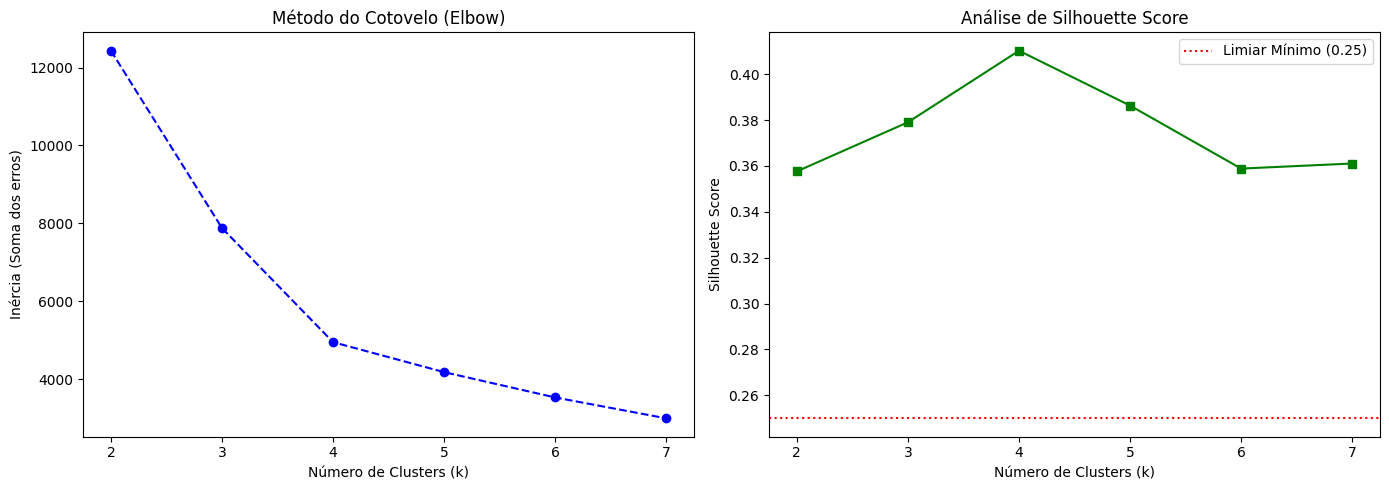


--- Teste de Estabilidade com diferentes Seeds (Para K=3) ---
Seed 0: Inércia = 1999.18
Seed 1: Inércia = 2006.80
Seed 2: Inércia = 1998.93
Seed 42: Inércia = 2003.99
Seed 100: Inércia = 1998.91


['modelo_kmeans.joblib']

In [5]:
# Selecionar APENAS as variáveis numéricas normalizadas para o K-Means
# (K-Means não lida bem com categorias)
X = preprocessor_num.fit_transform(df)

# MÉTODO DO COTOVELO E SILHOUETTE
inercia = []
silhouette_scores = []
k_range = range(2, 8) 

print("Treinando o K-Means para diferentes valores de K...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inercia.append(kmeans.inertia_)
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)

# Gráficos de Avaliação
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Cotovelo
ax1.plot(k_range, inercia, marker='o', linestyle='--', color='b')
ax1.set_title('Método do Cotovelo (Elbow)')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia (Soma dos erros)')

# Gráfico 2: Silhouette
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_title('Análise de Silhouette Score')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.axhline(y=0.25, color='r', linestyle=':', label='Limiar Mínimo (0.25)')
ax2.legend()

plt.tight_layout()
plt.show()

# TESTE DE ESTABILIDADE
print("\n--- Teste de Estabilidade com diferentes Seeds (Para K=3) ---")
seeds = [0, 1, 2, 42, 100]
for seed in seeds:
    kmeans_test = KMeans(n_clusters=10, random_state=seed, n_init=10)
    kmeans_test.fit(X)
    print(f"Seed {seed}: Inércia = {kmeans_test.inertia_:.2f}")

joblib.dump(kmeans, 'modelo_kmeans.joblib')

In [44]:
# Definindo as listas explicitamente para garantir que não há duplicação cruzada
colunas_numericas = ['Valor', 'Hora']
colunas_categoricas = ['Madrugada', 'Dia_de_Pagamento', 'Valor_Redondo', 'Status_Pendente', 'Mesmo_Banco', 'Dia_do_Mes']

# Junta tudo mantendo a ordem exata
todas_colunas = colunas_numericas + colunas_categoricas
df_kproto = df[todas_colunas].copy()

# Padronização das numéricas
scaler = StandardScaler()
df_kproto[colunas_numericas] = scaler.fit_transform(df_kproto[colunas_numericas])

# list.index() devolve 100% de certeza um número inteiro
indices_categoricos = [todas_colunas.index(col) for col in colunas_categoricas]

# Treinar o K-Prototypes
print("Treinando o K-Prototypes...")
kproto = KPrototypes(n_clusters=3, init='Cao', random_state=42, n_jobs=-1)

# Passar .values converte para matriz numpy, e nossos índices agora são inteiros garantidos
clusters_kproto = kproto.fit_predict(df_kproto.values, categorical=indices_categoricos)

df['Cluster_KPrototypes'] = clusters_kproto
print("Concluído! Perfis categóricos criados.")

joblib.dump(kproto, 'modelo_proto.joblib')

Treinando o K-Prototypes...
Concluído! Perfis categóricos criados.


['modelo_proto.joblib']

In [43]:
# Definimos a lista de colunas numéricas com a variável correta
colunas_numericas = ['Valor', 'Hora']

# Selecionamos apenas as numéricas (já que a matemática do PAM funciona melhor com elas)
X_num = df[colunas_numericas]

print("Treinando o K-Medoids (PAM)...")
# Usamos K=5 novamente para manter a coerência
kmedoids = KMedoids(n_clusters=10, random_state=42, init='k-medoids++')
clusters_kmed = kmedoids.fit_predict(X_num)

df['Cluster_KMedoides'] = clusters_kmed
print("Concluído! Clusters resistentes a outliers criados.")
joblib.dump(kmedoids, 'modelo_kmedoids.joblib')

Treinando o K-Medoids (PAM)...
Concluído! Clusters resistentes a outliers criados.


['modelo_kmedoids.joblib']

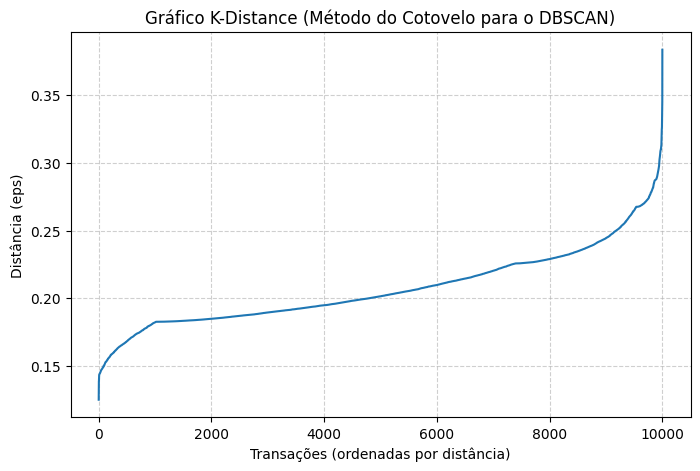

In [8]:
# Padronizar os dados
colunas_numericas = ['Valor', 'Hora', 'Dia_do_Mes']
scaler = StandardScaler()
X_num_padronizado = scaler.fit_transform(df[colunas_numericas])

# Calcular a distância para os 'k' vizinhos (usamos k=10, igual ao min_samples)
k = 10 
vizinhos = NearestNeighbors(n_neighbors=k)
vizinhos_fit = vizinhos.fit(X_num_padronizado)
distancias, indices = vizinhos_fit.kneighbors(X_num_padronizado)

# Ordenar as distâncias do 10 vizinho de cada ponto e fazer o gráfico
distancias = np.sort(distancias[:, k-1], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distancias)
plt.title('Gráfico K-Distance (Método do Cotovelo para o DBSCAN)')
plt.xlabel('Transações (ordenadas por distância)')
plt.ylabel('Distância (eps)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [9]:
print("A treinar o DBSCAN para isolar anomalias...")

dbscan = DBSCAN(eps=0.22, min_samples=10)
clusters_dbscan = dbscan.fit_predict(X_num_padronizado)

df['Cluster_DBSCAN'] = clusters_dbscan

ruidos_encontrados = (df['Cluster_DBSCAN'] == -1).sum()
print(f"Concluído! O DBSCAN classificou {ruidos_encontrados} transações como Ruído (Possíveis Fraudes).")

joblib.dump(dbscan, 'modelo_dbscan_euc.joblib')

A treinar o DBSCAN para isolar anomalias...
Concluído! O DBSCAN classificou 268 transações como Ruído (Possíveis Fraudes).


['modelo_dbscan_euc.joblib']

In [59]:
print("Preparando dados e calculando a matriz de distância Gower...")

# Definindo as colunas
colunas_numericas = ['Valor', 'Hora']
colunas_categoricas = ['Madrugada', 'Dia_de_Pagamento', 'Valor_Redondo', 'Status_Pendente', 'Mesmo_Banco', 'Dia_do_Mes']

# Criando o dataframe para o Gower e padronizando apenas as numéricas
df_gower = df[colunas_numericas + colunas_categoricas].copy()
scaler = StandardScaler()
df_gower[colunas_numericas] = scaler.fit_transform(df_gower[colunas_numericas])

# Calculando a matriz de distância
matriz_distancia = gower.gower_matrix(df_gower)

print("Treinando o DBSCAN com Gower...")
# eps ajustado para a escala de 0 a 1 do Gower
dbscan_gower = DBSCAN(eps=0.032, min_samples=5, metric='precomputed')
df['Cluster_DBSCAN_Gower'] = dbscan_gower.fit_predict(matriz_distancia)

# Contagem
ruidos_gower = (df['Cluster_DBSCAN_Gower'] == -1).sum()
print(f"Concluído! O DBSCAN com Gower isolou {ruidos_gower} transações como Ruído.")
joblib.dump(dbscan_gower, 'modelo_dbscan_gow.joblib')

Preparando dados e calculando a matriz de distância Gower...
Treinando o DBSCAN com Gower...
Concluído! O DBSCAN com Gower isolou 238 transações como Ruído.


['modelo_dbscan_gow.joblib']

In [56]:
print("Preparando dados e treinando o Isolation Forest...")

colunas_numericas = ['Valor', 'Hora']
colunas_categoricas = ['Madrugada', 'Dia_de_Pagamento', 'Valor_Redondo', 'Status_Pendente', 'Mesmo_Banco', 'Dia_do_Mes']

# O Isolation Forest lida melhor com categóricas com One-Hot Encoding
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), colunas_numericas),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), colunas_categoricas)
])

X_if = preprocessor.fit_transform(df[colunas_numericas + colunas_categoricas])

# Treinando
# 'contamination' é a estimativa de fraudes na base
iso_forest = IsolationForest(contamination=0.013, random_state=42)

# O modelo retorna 1 para normal e -1 para anomalia
df['Cluster_IsolationForest'] = iso_forest.fit_predict(X_if)

# Contagem
anomalias_if = (df['Cluster_IsolationForest'] == -1).sum()
print(f"Concluído! O Isolation Forest detectou {anomalias_if} possíveis fraudes.")
joblib.dump(iso_forest, 'modelo_iforest.joblib')

Preparando dados e treinando o Isolation Forest...
Concluído! O Isolation Forest detectou 130 possíveis fraudes.


['modelo_iforest.joblib']

In [58]:
cols_num = ['Valor', 'Hora', 'Dia_do_Mes']
cols_cat = ['Madrugada', 'Dia_de_Pagamento', 'Valor_Redondo', 'Status_Pendente', 'Mesmo_Banco']
todas_cols = cols_num + cols_cat

# Padronizando novamente
scaler = StandardScaler()
X_num_padronizado = scaler.fit_transform(df[cols_num])

# Base para o K-Prototypes e Gower
df_misto = df[todas_cols].copy()
df_misto[cols_num] = X_num_padronizado
indices_categoricos = [todas_cols.index(col) for col in cols_cat]

# Base para o Isolation Forest (OneHotEncoding nas categóricas)
preprocessor = ColumnTransformer([
    ('num', 'passthrough', cols_num), 
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cols_cat)
])
X_if = preprocessor.fit_transform(df_misto)

print("MÉTRICAS EXTRAS DE COESÃO E SEPARAÇÃO")

# K-Means
km = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_num_padronizado)
print(f"[K-Means] Davies-Bouldin: {davies_bouldin_score(X_num_padronizado, km.labels_):.4f} | Calinski-Harabasz: {calinski_harabasz_score(X_num_padronizado, km.labels_):.2f}")

# K-Medóides
kmed = KMedoids(n_clusters=5, random_state=42, init='k-medoids++').fit(X_num_padronizado)
print(f"[K-Medóides] Davies-Bouldin: {davies_bouldin_score(X_num_padronizado, kmed.labels_):.4f} | Calinski-Harabasz: {calinski_harabasz_score(X_num_padronizado, kmed.labels_):.2f}")

# Justificativas para o Relatório
print("\n[K-Prototypes] Justificativa: Métricas de coesão contínua pura do sklearn não dão suporte a distância mista (categórica).")
print("[DBSCAN & Gower] Justificativa: Algoritmos de densidade possuem ruído (-1). O conceito de centroide esférico não se aplica.")
print("[Isolation Forest] Justificativa: O algoritmo separa por cortes em árvores de decisão (Path Length), não por coesão espacial.")

print("\nTESTE DE ESTABILIDADE DOS CLUSTERS (ARI comparado à Seed 0)")
seeds = [1, 2, 42, 100]

# K-Means
labels_km_0 = KMeans(n_clusters=5, random_state=0, n_init=10).fit_predict(X_num_padronizado)
ari_km = [adjusted_rand_score(labels_km_0, KMeans(n_clusters=5, random_state=s, n_init=10).fit_predict(X_num_padronizado)) for s in seeds]
print(f"[K-Means] Estabilidade Média (ARI): {np.mean(ari_km):.4f}")

# K-Medóides
labels_kmed_0 = KMedoids(n_clusters=5, random_state=0, init='k-medoids++').fit_predict(X_num_padronizado)
ari_kmed = [adjusted_rand_score(labels_kmed_0, KMedoids(n_clusters=5, random_state=s, init='k-medoids++').fit_predict(X_num_padronizado)) for s in seeds]
print(f"[K-Medóides] Estabilidade Média (ARI): {np.mean(ari_kmed):.4f}")

# K-Prototypes
labels_kp_0 = KPrototypes(n_clusters=5, init='Cao', random_state=0, n_jobs=-1).fit_predict(df_misto.values, categorical=indices_categoricos)
ari_kp = [adjusted_rand_score(labels_kp_0, KPrototypes(n_clusters=5, init='Cao', random_state=s, n_jobs=-1).fit_predict(df_misto.values, categorical=indices_categoricos)) for s in seeds]
print(f"[K-Prototypes] Estabilidade Média (ARI): {np.mean(ari_kp):.4f}")

# Isolation Forest
labels_if_0 = IsolationForest(contamination=0.05, random_state=0).fit_predict(X_if)
ari_if = [adjusted_rand_score(labels_if_0, IsolationForest(contamination=0.05, random_state=s).fit_predict(X_if)) for s in seeds]
print(f"[Isolation Forest] Estabilidade Média (ARI): {np.mean(ari_if):.4f}")

print("\n[DBSCAN & Gower] Justificativa: São algoritmos estritamente determinísticos. Não usam sementes aleatórias (ARI = 1.0 sempre).")

print("TESTE DE MÚLTIPLAS MÉTRICAS DE DISTÂNCIA")

# K-Medóides
kmed_euc = KMedoids(n_clusters=5, random_state=42, metric='euclidean').fit_predict(X_num_padronizado)
kmed_man = KMedoids(n_clusters=5, random_state=42, metric='manhattan').fit_predict(X_num_padronizado)
print(f"[K-Medóides] Coesão Davies-Bouldin -> Euclidiana: {davies_bouldin_score(X_num_padronizado, kmed_euc):.4f} | Manhattan: {davies_bouldin_score(X_num_padronizado, kmed_man):.4f}")

# DBSCAN
print("\nCalculando matriz Gower para comparação do DBSCAN...")
matriz_gower = gower.gower_matrix(df_misto)

db_euc = (DBSCAN(eps=0.30, min_samples=5, metric='euclidean').fit_predict(X_num_padronizado) == -1).sum()
db_man = (DBSCAN(eps=0.30, min_samples=5, metric='manhattan').fit_predict(X_num_padronizado) == -1).sum()
db_gow = (DBSCAN(eps=0.03, min_samples=5, metric='precomputed').fit_predict(matriz_gower) == -1).sum()

print(f"[DBSCAN] Ruídos isolados -> Euclidiana: {db_euc} | Manhattan: {db_man} | Gower: {db_gow}")

print("\n[K-Means] Justificativa: Suporta apenas distância Euclidiana no scikit-learn.")
print("[Isolation Forest] Justificativa: Não utiliza métricas de distância espacial, apenas cortes ortogonais.")

MÉTRICAS EXTRAS DE COESÃO E SEPARAÇÃO
[K-Means] Davies-Bouldin: 1.0604 | Calinski-Harabasz: 3803.19


KeyboardInterrupt: 

Carregando modelos salvos do disco...
K-Means
Acurácia: 84.79% | Precisão: 1.57% | Recall: 23.00% | F1-Score: 2.94%

K-Medóides
Acurácia: 1.00% | Precisão: 1.00% | Recall: 100.00% | F1-Score: 1.98%

K-Prototypes
Acurácia: 66.43% | Precisão: 1.32% | Recall: 44.00% | F1-Score: 2.55%

DBSCAN (Euclidiana)
Acurácia: 96.46% | Precisão: 2.61% | Recall: 7.00% | F1-Score: 3.80%

DBSCAN (Gower)
Acurácia: 96.98% | Precisão: 7.56% | Recall: 18.00% | F1-Score: 10.65%

Isolation Forest
Acurácia: 98.02% | Precisão: 12.31% | Recall: 16.00% | F1-Score: 13.91%



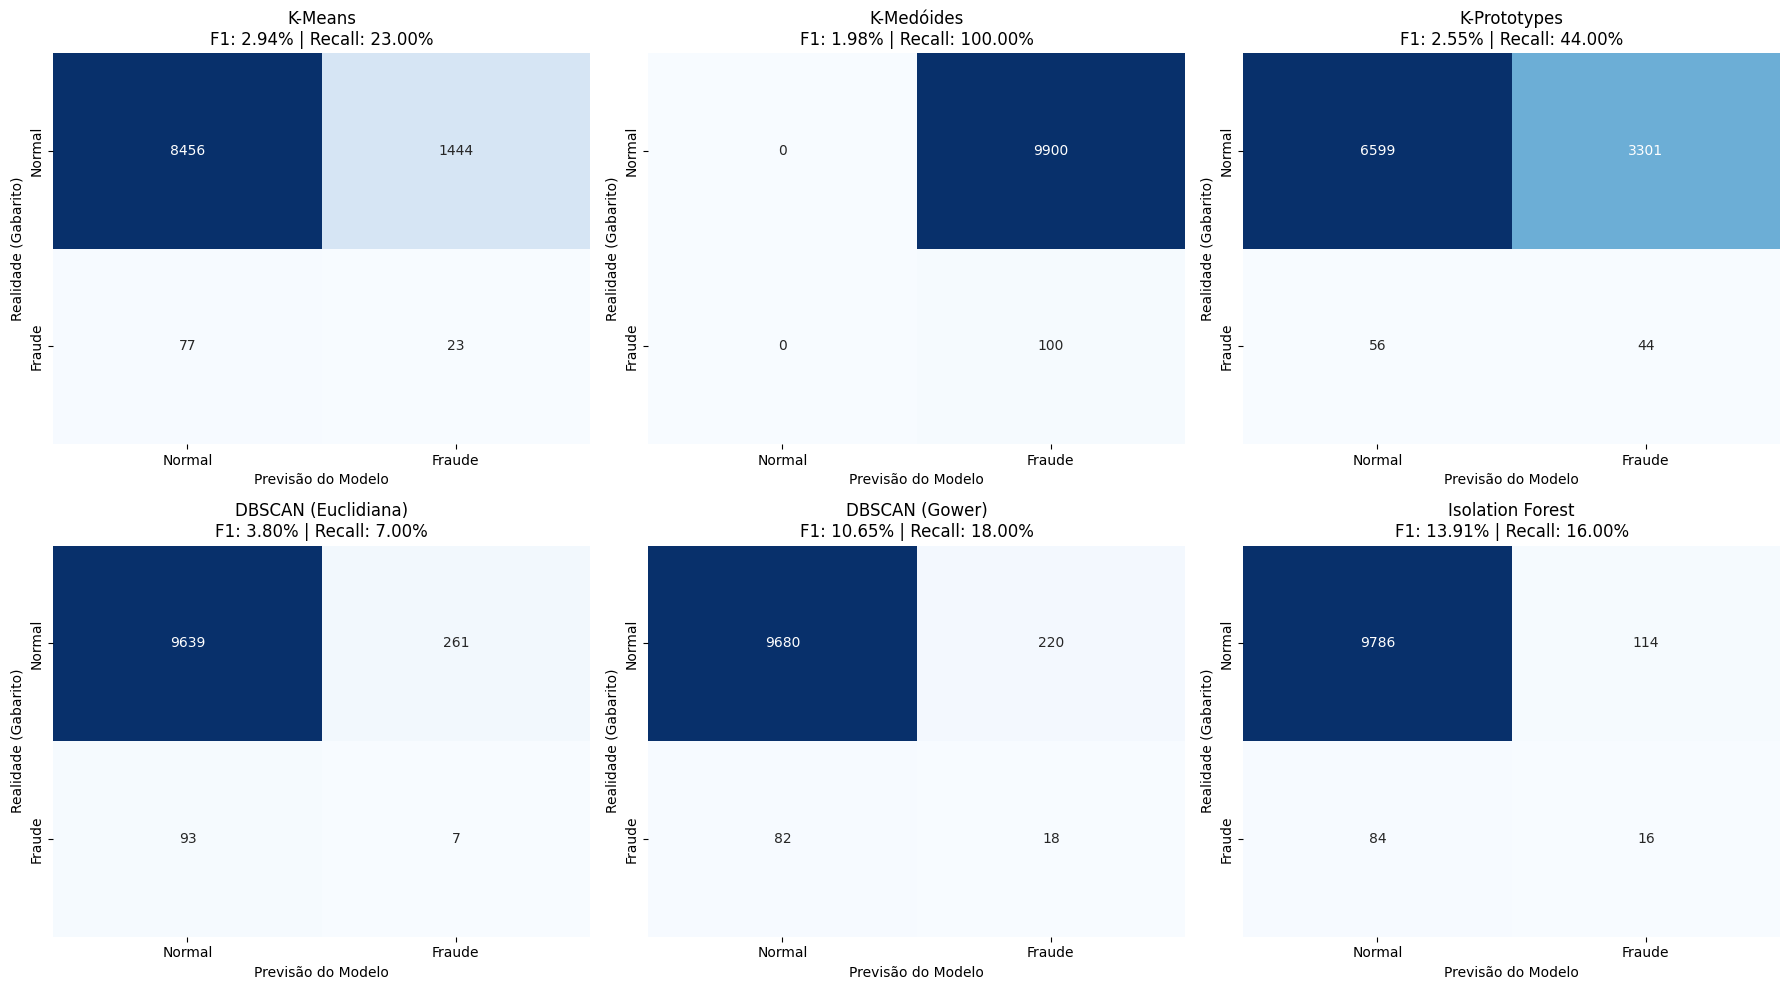

In [60]:
cols_num = ['Valor', 'Hora']
cols_cat = ['Madrugada', 'Dia_de_Pagamento', 'Valor_Redondo', 'Status_Pendente', 'Mesmo_Banco', 'Dia_do_Mes']
todas_cols = cols_num + cols_cat

scaler = StandardScaler()
X_num_pad = scaler.fit_transform(df[cols_num])

df_misto = df[todas_cols].copy()
df_misto[cols_num] = X_num_pad
indices_cat = [todas_cols.index(col) for col in cols_cat]

preprocessor = ColumnTransformer([
    ('num', 'passthrough', cols_num),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cols_cat)
])
X_if = preprocessor.fit_transform(df_misto)

# Carregando os Modelos Salvos 
print("Carregando modelos salvos do disco...")
kmeans_load = joblib.load('modelo_kmeans.joblib')
kmedoids_load = joblib.load('modelo_kmedoids.joblib')
kproto_load = joblib.load('modelo_proto.joblib')
dbscan_euc_load = joblib.load('modelo_dbscan_euc.joblib')
dbscan_gow_load = joblib.load('modelo_dbscan_gow.joblib')
iforest_load = joblib.load('modelo_iforest.joblib')

# Gerando Previsões sem Retreinar
df['Cluster_KMeans'] = kmeans_load.predict(X_num_pad)
df['Cluster_KMedoides'] = kmedoids_load.predict(X_num_pad)
df['Cluster_KPrototypes'] = kproto_load.predict(df_misto.values, categorical=indices_cat)
df['Cluster_DBSCAN'] = dbscan_euc_load.labels_ # DBSCAN usa labels_ armazenadas
df['Cluster_DBSCAN_Gower'] = dbscan_gow_load.labels_
df['Cluster_IsolationForest'] = iforest_load.predict(X_if)

# Comparativo Visual (Matrizes)
colunas_modelos = [
    'Cluster_KMeans', 'Cluster_KMedoides', 'Cluster_KPrototypes', 
    'Cluster_DBSCAN', 'Cluster_DBSCAN_Gower', 'Cluster_IsolationForest'
]
nomes_modelos = [
    'K-Means', 'K-Medóides', 'K-Prototypes', 
    'DBSCAN (Euclidiana)', 'DBSCAN (Gower)', 'Isolation Forest'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
gabarito = df['Anomalia']

for i, col in enumerate(colunas_modelos):
    if 'DBSCAN' in col or 'IsolationForest' in col:
        previsoes = (df[col] == -1).astype(int)
    else:
        taxa_fraude = df.groupby(col)['Anomalia'].mean()
        cluster_suspeito = taxa_fraude.idxmax()
        previsoes = (df[col] == cluster_suspeito).astype(int)

    acc = accuracy_score(gabarito, previsoes)
    prec = precision_score(gabarito, previsoes, zero_division=0)
    rec = recall_score(gabarito, previsoes)
    f1 = f1_score(gabarito, previsoes)

    print(f"{nomes_modelos[i]}")
    print(f"Acurácia: {acc*100:.2f}% | Precisão: {prec*100:.2f}% | Recall: {rec*100:.2f}% | F1-Score: {f1*100:.2f}%\n")

    cm = confusion_matrix(gabarito, previsoes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'], cbar=False)
    
    axes[i].set_title(f'{nomes_modelos[i]}\nF1: {f1*100:.2f}% | Recall: {rec*100:.2f}%')
    axes[i].set_ylabel('Realidade (Gabarito)')
    axes[i].set_xlabel('Previsão do Modelo')

plt.tight_layout()
plt.show()

In [61]:
print("Iniciando a extração de Regras de Negócio com o Apriori...\n")

# Discretização
df['Valor_Baixo'] = (df['Valor'] < 2000).astype(int)
df['Hora_Noite'] = (df['Hora'] > 18).astype(int)

colunas_regra = [
    'Madrugada', 'Valor_Redondo', 'Valor_Baixo', 'Hora_Noite', 
    'Status_Pendente', 'Mesmo_Banco', 'Anomalia'
]

# Converter para booleano
df_apriori = df[colunas_regra].astype(bool)

# Mineração de Padrões Frequentes
padroes = apriori(df_apriori, min_support=0.001, use_colnames=True)

# Gerar Regras
regras = association_rules(padroes, metric="confidence", min_threshold=0.01)

# Apenas as regras onde o RESULTADO é Anomalia
regras_fraude = regras[regras['consequents'] == frozenset({'Anomalia'})]

# Pegar estritamente apenas as 3 melhores regras
top_4_regras = regras_fraude.sort_values(by='confidence', ascending=False).head(4)

print(f"Focando a análise nas 4 regras de maior risco (Top 4):")

for i, row in top_4_regras.iterrows():
    antecedentes = " E ".join(list(row['antecedents']))
    confianca = row['confidence'] * 100
    lift = row['lift']
    print(f"SE [{antecedentes}] ENTÃO é Fraude (Confiança: {confianca:.2f}% | Multiplicador de Risco: {lift:.2f})")

Iniciando a extração de Regras de Negócio com o Apriori...

Focando a análise nas 4 regras de maior risco (Top 4):
SE [Valor_Redondo E Valor_Baixo] ENTÃO é Fraude (Confiança: 32.84% | Multiplicador de Risco: 32.84)
SE [Valor_Redondo] ENTÃO é Fraude (Confiança: 17.83% | Multiplicador de Risco: 17.83)
SE [Hora_Noite E Valor_Baixo] ENTÃO é Fraude (Confiança: 1.78% | Multiplicador de Risco: 1.78)
SE [Hora_Noite] ENTÃO é Fraude (Confiança: 1.62% | Multiplicador de Risco: 1.62)



REDUÇÃO DE DIMENSIONALIDADE (PCA)

O PCA conseguiu reter 65.49% da informação original em apenas 3 dimensões!

Iniciando a otimização profunda de todos os modelos...

Otimização concluída! Modelos atualizados com os melhores parâmetros.
--- K-Means ---
Acurácia: 98.97% | Precisão: 44.83% | Recall: 13.00% | F1-Score: 20.16%

--- K-Medóides ---
Acurácia: 82.01% | Precisão: 1.76% | Recall: 31.00% | F1-Score: 3.33%

--- K-Prototypes ---
Acurácia: 68.63% | Precisão: 1.38% | Recall: 43.00% | F1-Score: 2.67%

--- DBSCAN (PCA) ---
Acurácia: 98.93% | Precisão: 18.18% | Recall: 2.00% | F1-Score: 3.60%

--- DBSCAN (Gower) ---
Acurácia: 97.80% | Precisão: 10.53% | Recall: 16.00% | F1-Score: 12.70%

--- Isolation Forest ---
Acurácia: 98.70% | Precisão: 20.00% | Recall: 10.00% | F1-Score: 13.33%



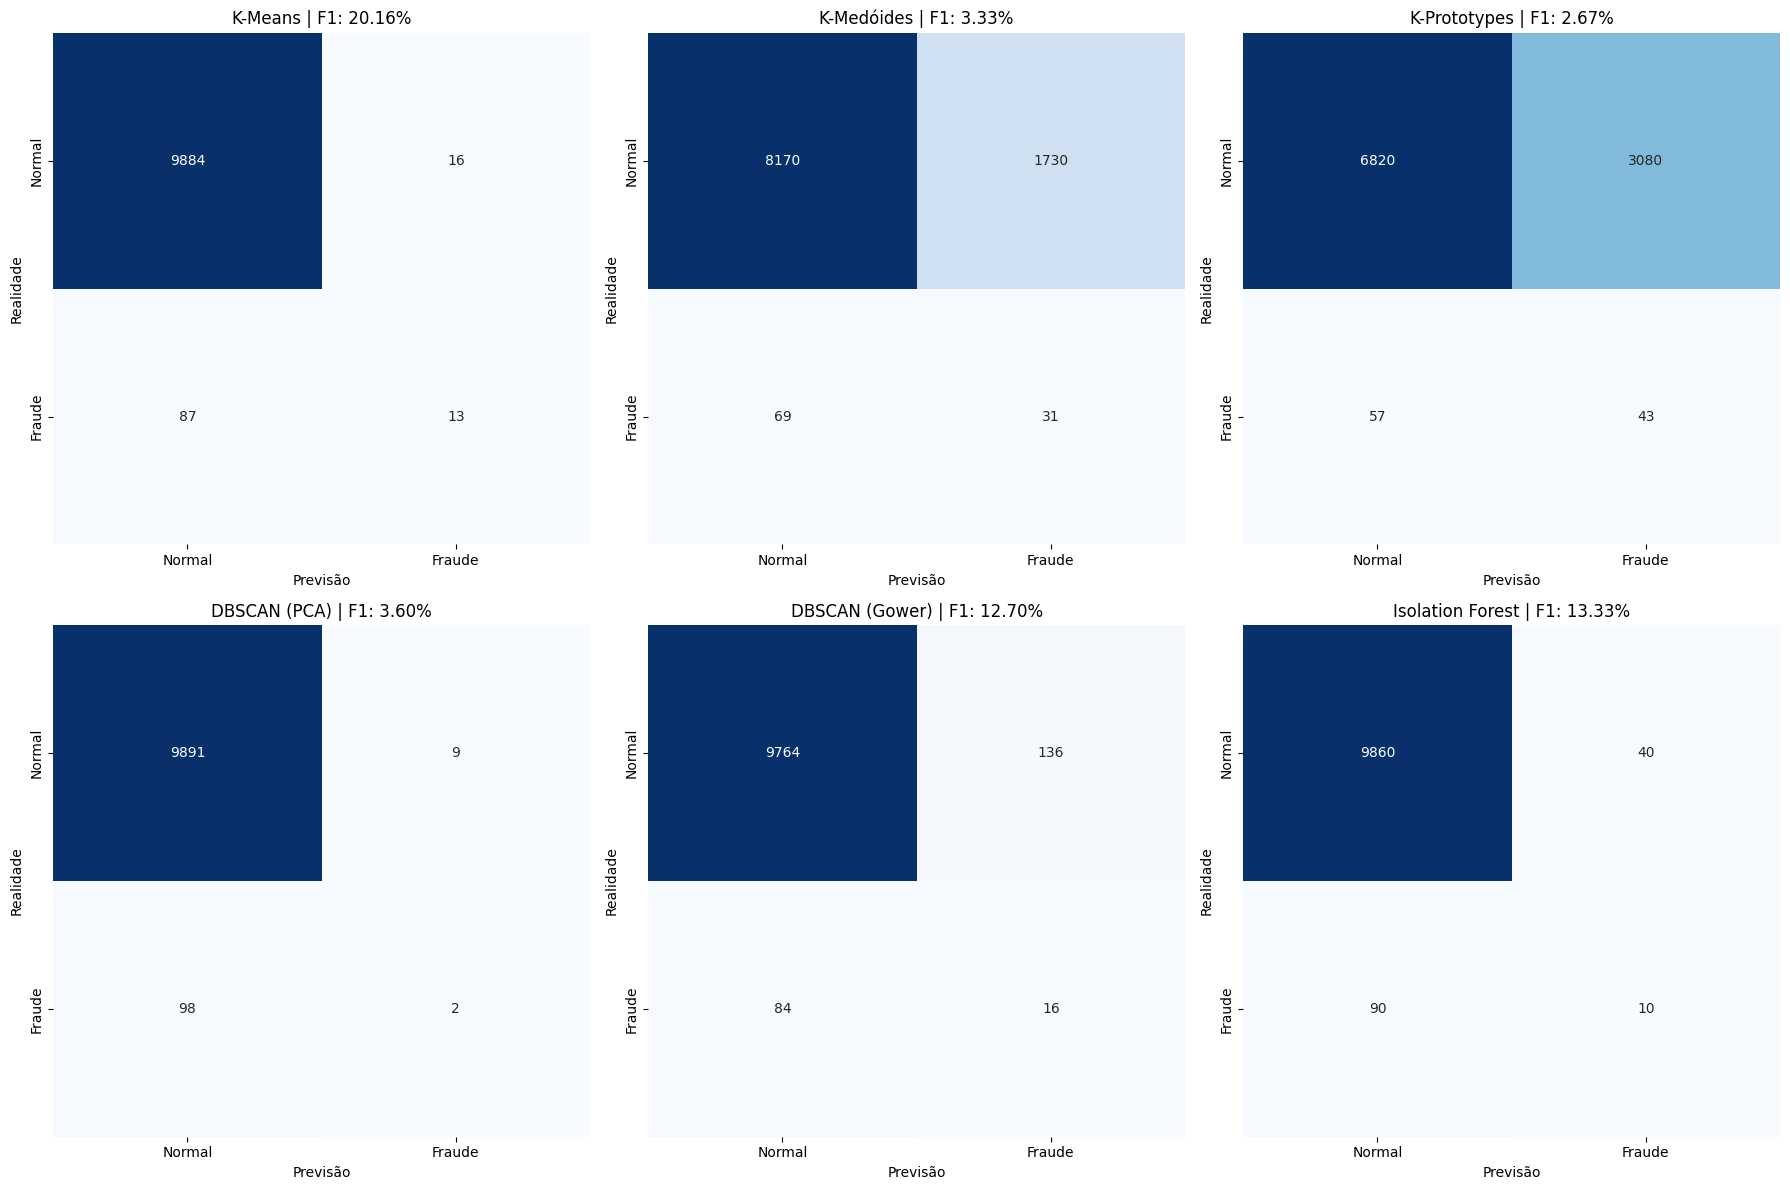

In [ ]:
# Regra 1: Valor Redondo E Valor Baixo (Risco Altíssimo: 32.84%)
df['Regra_Redondo_Baixo'] = ((df['Valor_Redondo'] == 1) & (df['Valor'] < 2000)).astype(int)

# Regra 3: Hora Noite E Valor Baixo (Risco: 1.78%)
df['Regra_Noite_Baixo'] = ((df['Hora'] > 18) & (df['Valor'] < 2000)).astype(int)

# As regras 2 e 4 (apenas Redondo e apenas Noite) já estão contidas nas variáveis 
# categóricas padrão e na composição das regras compostas acima.

print("\nREDUÇÃO DE DIMENSIONALIDADE (PCA)\n")

var_num = ['Valor', 'Hora'] 
var_binarias = ['Regra_Redondo_Baixo', 'Regra_Noite_Baixo'] 

# Removemos DiaDaSemana, FimDeSemana, Mesmo_Banco, TipoChave...
var_cat_limpas = ['Madrugada', 'Dia_do_Mes', 'Dia_de_Pagamento', 'Valor_Redondo', 'Status']

# PREPARAÇÃO DA BASE BASE
prep_pca = ColumnTransformer([
    ('num', StandardScaler(), var_num),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), var_cat_limpas)
])

X_base_para_reduzir = prep_pca.fit_transform(df)

# PCA 
pca = PCA(n_components=3, random_state=42)
X_comprimido = pca.fit_transform(X_base_para_reduzir)

var_explicada = sum(pca.explained_variance_ratio_) * 100
print(f"O PCA conseguiu reter {var_explicada:.2f}% da informação original em apenas 3 dimensões!\n")

# INJETANDO AS REGRAS
peso_regras = 10
# Agora juntamos os 3 componentes super densos com as nossas regras hiper pesadas
X_dbscan_pca = np.hstack((X_comprimido, df[var_binarias].values * peso_regras))

# Preprocessor para Isolation Forest
preprocessor = ColumnTransformer([
    ('num', 'passthrough', var_num + var_binarias), 
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), var_cat)
])

print("Iniciando a otimização profunda de todos os modelos...\n")

gabarito = df['Anomalia']

# Definição dos Espaços de Busca
grids = {
    'KMeans': {'n_clusters': [10, 15, 20, 30, 40, 50]},
    'DBSCAN': {'eps': [5.0], 'min_samples': [5, 10, 15]},
    'IsolationForest': {'contamination': [0.005, 0.01, 0.02, 0.03, 0.05], 'n_estimators': [300, 500], 'max_features': [0.3, 0.5, 0.7, 1.0], 'max_samples': [128, 256, 512], 'bootstrap': [True, False]}
}

# Otimização do KMeans
best_f1, best_params = -1, {}
for params in ParameterGrid(grids['KMeans']):
    model = KMeans(**params, random_state=42, n_init=10).fit(X_num_pad)
    labels = model.labels_
    taxa_fraude = pd.Series(labels, name='c').to_frame().join(gabarito.rename('a')).groupby('c')['a'].mean()
    pred = (labels == taxa_fraude.idxmax()).astype(int)
    f1 = f1_score(gabarito, pred)
    if f1 > best_f1: best_f1, best_params = f1, params
df['Cluster_KMeans'] = KMeans(**best_params, random_state=42, n_init=10).fit_predict(X_dbscan_pca)

# Otimização do DBSCAN
best_f1, best_params = -1, {}
for params in ParameterGrid(grids['DBSCAN']):
    pred = DBSCAN(**params).fit_predict(X_dbscan_pca)
    f1 = f1_score(gabarito, (pred == -1).astype(int))
    if f1 > best_f1: 
        best_f1 = f1
        best_params = params
df['Cluster_DBSCAN_Euclidiano_PCA'] = DBSCAN(**best_params).fit_predict(X_dbscan_pca)

# Otimização do Isolation Forest
best_f1, best_params = -1, {}
for params in ParameterGrid(grids['IsolationForest']):
    pred = IsolationForest(**params, random_state=42).fit_predict(X_if)
    f1 = f1_score(gabarito, (pred == -1).astype(int))
    if f1 > best_f1: best_f1, best_params = f1, params
    
# Aplica o melhor modelo no pipeline final
best_if = IsolationForest(**best_params, random_state=42)
df['Cluster_IsolationForest'] = best_if.fit_predict(X_if) 

# DBSCAN Gower (Mantemos fixo pois o cálculo da matriz é custoso)
df['Cluster_DBSCAN_Gower'] = DBSCAN(eps=0.05, min_samples=3, metric='precomputed').fit_predict(matriz_distancia)

# KMedoids e KPrototypes (Mantemos fixos pela complexidade de busca)
df['Cluster_KMedoides'] = KMedoids(n_clusters=5, random_state=42, init='k-medoids++').fit_predict(X_num_pad)
df['Cluster_KPrototypes'] = KPrototypes(n_clusters=3, init='Cao', random_state=42, n_jobs=1).fit_predict(df_misto.values, categorical=indices_cat)

print("Otimização concluída! Modelos atualizados com os melhores parâmetros.")

# Comparativo Visual (Matrizes e Métricas)
colunas_modelos = [
    'Cluster_KMeans', 'Cluster_KMedoides', 'Cluster_KPrototypes', 
    'Cluster_DBSCAN_Euclidiano_PCA', 'Cluster_DBSCAN_Gower', 'Cluster_IsolationForest'
]
nomes_modelos = [
    'K-Means', 'K-Medóides', 'K-Prototypes', 
    'DBSCAN (PCA)', 'DBSCAN (Gower)', 'Isolation Forest'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(colunas_modelos):
    if 'DBSCAN' in col or 'IsolationForest' in col:
        previsoes = (df[col] == -1).astype(int)
    else:
        taxa_fraude = df.groupby(col)['Anomalia'].mean()
        cluster_suspeito = taxa_fraude.idxmax()
        previsoes = (df[col] == cluster_suspeito).astype(int)

    acc = accuracy_score(gabarito, previsoes)
    prec = precision_score(gabarito, previsoes, zero_division=0)
    rec = recall_score(gabarito, previsoes)
    f1 = f1_score(gabarito, previsoes)

    print(f"--- {nomes_modelos[i]} ---")
    print(f"Acurácia: {acc*100:.2f}% | Precisão: {prec*100:.2f}% | Recall: {rec*100:.2f}% | F1-Score: {f1*100:.2f}%\n")

    cm = confusion_matrix(gabarito, previsoes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'], cbar=False)
    axes[i].set_title(f'{nomes_modelos[i]} | F1: {f1*100:.2f}%')
    axes[i].set_ylabel('Realidade')
    axes[i].set_xlabel('Previsão')

plt.tight_layout()
plt.show()

In [63]:
# Usamos o mesmo df_apriori que criámos antes
# O FP-Growth costuma ser mais rápido em bases densas
padroes_fp = fpgrowth(df_apriori, min_support=0.002, use_colnames=True)

# Gerar as regras da mesma forma que fizemos no Apriori
regras_fp = association_rules(padroes_fp, metric="confidence", min_threshold=0.01)

# Filtrar resultados
regras_fraude_fp = regras_fp[regras_fp['consequents'] == frozenset({'Anomalia'})]
print("Top 4 Regras do FP-Growth:")
print(regras_fraude_fp.sort_values(by='confidence', ascending=False).head(4))

Top 4 Regras do FP-Growth:
                     antecedents consequents  antecedent support  \
91  (Valor_Redondo, Valor_Baixo)  (Anomalia)              0.0067   
89               (Valor_Redondo)  (Anomalia)              0.0129   
82                  (Hora_Noite)  (Anomalia)              0.2158   
87                 (Valor_Baixo)  (Anomalia)              0.3963   

    consequent support  support  confidence       lift  representativity  \
91                0.01   0.0022    0.328358  32.835821               1.0   
89                0.01   0.0023    0.178295  17.829457               1.0   
82                0.01   0.0035    0.016219   1.621872               1.0   
87                0.01   0.0051    0.012869   1.286904               1.0   

    leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
91  0.002133    1.474000       0.976085  0.151724   0.321574    0.274179  
89  0.002171    1.204811       0.956249  0.111650   0.169995    0.204147  
82  0.001342    1.006321  